# M2K Donchian channel breakout, long-only, 15-minute bars (Tradovate exchange)

Same event-driven engine, cost model, and strategy
(`backtester.strategies.DonchianBreakoutStrategy`) as
`donchian_breakout_mes.ipynb`, applied to **M2K** instead of MES --
real OHLC resampled locally from Databento's full-history 1-minute
M2K continuous-contract Parquet file, whole-contract position
sizing, tick-based slippage + per-contract fees, Tradeify-style EOD-trailing
drawdown risk middleware.

**Why this pass exists**: the MES version of this notebook found the first
statistically defensible (walk-forward-validated, positive out-of-sample
Sharpe lower bound) result in this repo's research program --
`direction=long`, 15-minute bars, short lookback (5-20 bars), R:R 2.5-4x. That
result was driven partly by a structural, MES-specific observation (the
index's 2019-2026 bull drift makes long breakouts swim with the tape and short
breakouts fight it). M2K shares the same broad equity-index bull
drift over this period, so the same mechanism is plausible here too -- this
pass checks whether it actually transfers, starting `direction=long` from the
outset (not re-discovering the long-bias finding from scratch) and reusing the
exact same length/R:R grid as the validated MES pass for direct comparability.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import DonchianBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "M2K"
SYMBOL = "M2K/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/M2K_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 167703  span: 2019-05-05 22:14:59.999000 -> 2026-07-13 07:14:59.999000


## Grid search: channel length x risk:reward ratio, direction=long

Same grid as the validated MES pass: `length` in {10,20,30,40,50,75,100} x
`risk_reward_ratio` in {1.0,1.25,1.5,2.0,2.5,3.0} -- 42 combos,
`direction=long` throughout (not `both`), per the MES long-bias finding.


In [3]:
LENGTH_CANDIDATES = [10, 20, 30, 40, 50, 75, 100]
RISK_REWARD_RATIO_CANDIDATES = [1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
DEPOSIT_USD = 50_000  # Tradeify Growth $50k account, same convention as the other notebooks


def run_donchian_backtest(length: int, risk_reward_ratio: float):
    lower, upper = Indicators.donchian_channels(ohlc, length=length)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="upper", df=upper)
    combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                indicator_name="lower", df=lower)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=DonchianBreakoutStrategy(
                key=f"DONCHIAN_{length}_{risk_reward_ratio}_{DISPLAY_SYMBOL}",
                market=combo_market,
                symbol=SYMBOL,
                upper_key="upper",
                lower_key="lower",
                risk_reward_ratio=risk_reward_ratio,
                direction=StrategyDirection.long,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for rr in RISK_REWARD_RATIO_CANDIDATES:
        bt, drawdown_mw = run_donchian_backtest(length, rr)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
        )
        grid_backtests[(length, rr)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length,
            "risk_reward_ratio": rr,
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1),
            "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"],
            "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"],
            "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s, {len(grid_results)} combos\n")
print(grid_results.head(15).to_string())


length=10 done, 80s elapsed


length=20 done, 136s elapsed


length=30 done, 195s elapsed


length=40 done, 263s elapsed


length=50 done, 338s elapsed


length=75 done, 422s elapsed


length=100 done, 562s elapsed



grid done in 563s, 42 combos

    length  risk_reward_ratio  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0      100               3.00            33.62816      0.245696              -41.4820           94.0             13.1         25.531915       1.246341               0.021277              1.124726         150.829787         1011.92           False
1       30               1.00            15.48320      0.166772              -35.6184         1185.0            164.6         51.054852       1.091020               0.021097              1.053849          15.727234        10910.90           False
2       20               1.25            11.69420      0.145951              -39.4792         1284.0            178.3         44.548287       1.075760               0.002336              1.050318          12.610397        10433.

### Heatmaps: Sharpe ratio and net return across (length, risk_reward_ratio)


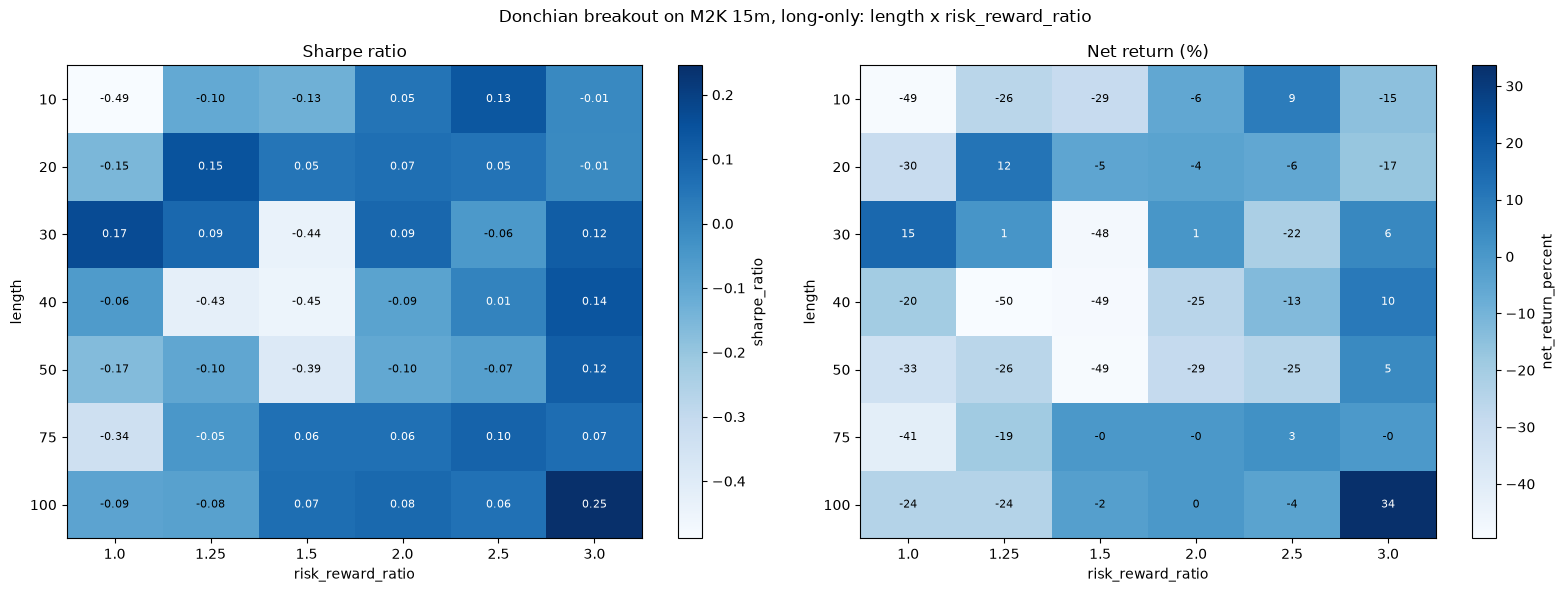

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("risk_reward_ratio")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="risk_reward_ratio", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="risk_reward_ratio", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Donchian breakout on {DISPLAY_SYMBOL} 15m, long-only: length x risk_reward_ratio")
fig.tight_layout()
plt.show()


## Holdout check: does the best combo survive a train/test split?

Same discipline as the MES notebook: freeze the last 25% of history, re-run
the grid's best combo on FULL / TRAIN / TEST.


In [5]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


def run_donchian_backtest_on(ohlc_slice: pd.DataFrame, length: int, risk_reward_ratio: float, key: str,
                              direction: StrategyDirection = StrategyDirection.long):
    lower, upper = Indicators.donchian_channels(ohlc_slice, length=length)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=DonchianBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, upper_key="upper", lower_key="lower",
            risk_reward_ratio=risk_reward_ratio, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


best_length, best_rr = grid_results.iloc[0][["length", "risk_reward_ratio"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, risk_reward_ratio={best_rr}\n")

holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_donchian_backtest_on(ohlc_slice, best_length, float(best_rr), key=f"DONCHIAN_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-25 15:59:59.999000  (125777 train bars, 41926 test bars)
Best combo: length=100, risk_reward_ratio=3.0



                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                         94         25.531915      0.074574        -0.095331        0.245696            33.62816              1.124726         150.829787              -41.4820           False
TRAIN (75%)                  76         26.315789      0.079811        -0.109184        0.277479            30.51466              1.157453         172.302632              -39.4435           False
TEST (last 25%, unseen)      20         20.000000      0.007717        -0.360122        0.185446             4.47618              0.984408         -18.025000              -28.0585           False
